In [407]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd

EVAL_JOBS_DIR = Path("/cvgl2/u/cgokmen/BEHAVIOR-1K/slurm/eval_jobs_no_rgb")
EVAL_SUCCESSES_DIR = Path("/cvgl2/u/cgokmen/BEHAVIOR-1K/slurm/eval_successes_no_rgb_longer")
EVAL_RESULTS_DIR = Path("/vision/group/vid2room/eval_results_no_rgb_longer")

In [408]:
from tqdm.auto import tqdm

def extract_policy_name(checkpoint_path: str) -> str:
    """e.g. '.../vid2room_pick_policies/vid2room-10/checkpoints/step_03000.pt' -> 'vid2room-10'"""
    return Path(checkpoint_path).parent.parent.name

# (dataset_name, policy_name) -> {"total": int, "success": int}
agg = defaultdict(lambda: {"total": 0, "success": 0})
completed, skipped = 0, 0

all_jobs = sorted(EVAL_JOBS_DIR.glob("*.json"))
for job_file in tqdm(all_jobs):
    job_id = job_file.stem
    success_file = EVAL_SUCCESSES_DIR / f"{job_id}.success"

    if not job_file.exists():
        continue

    job_cfg = json.loads(job_file.read_text())
    dataset_name = job_cfg["dataset_name"]
    policy_name = extract_policy_name(job_cfg["checkpoint_path"])

    if not success_file.exists():
        skipped += 1
        continue

    summary_file = EVAL_RESULTS_DIR / job_id / "run_summary.json"
    if not summary_file.exists():
        skipped += 1
        continue

    run_summary = json.loads(summary_file.read_text())
    for episode in run_summary:
        agg[(dataset_name, policy_name)]["total"] += 1
        if episode.get("success", False):
            agg[(dataset_name, policy_name)]["success"] += 1

    completed += 1

print(f"Completed jobs: {completed}/{len(all_jobs)}  (skipped {skipped} incomplete)")

  0%|          | 0/351 [00:00<?, ?it/s]

Completed jobs: 337/351  (skipped 14 incomplete)


In [409]:
import random

if False:
    SAMPLE_SIZE = 10
    for k in list(agg.keys()):
        # Generate the population
        population = [i < agg[k]["success"] for i in range(agg[k]["total"])]

        # Sample 10 elements
        sample = random.sample(population, k=SAMPLE_SIZE)

        # Update the agg
        agg[k]["success"] = sum(sample)
        agg[k]["total"] = SAMPLE_SIZE

In [410]:
completed_items = sum(v["total"] for v in agg.values())
expected_items = 13 * 3 * 50
print(f"Completed {completed_items}/{expected_items} items ({completed_items / expected_items:.1%})")

Completed 1840/1950 items (94.4%)


In [411]:
rows = []
for (dataset_name, policy_name), counts in agg.items():
    total = counts["total"]
    success = counts["success"]
    rows.append({
        "dataset_name": dataset_name,
        "policy_name": policy_name,
        "total": total,
        "success": success,
        "rate": success / total if total > 0 else 0.0,
    })

df = pd.DataFrame(rows)

# Pivot into a 2D table: rows = dataset_name, columns = policy_name
# Sort policy names: group by prefix, then by numeric suffix
def policy_sort_key(name: str):
    parts = name.rsplit("-", 1)
    prefix = parts[0]
    num = int(parts[1]) if len(parts) == 2 and parts[1].isdigit() else 0
    return (prefix, num)

policy_order = sorted(df["policy_name"].unique(), key=policy_sort_key)
dataset_order = sorted(df["dataset_name"].unique())

rate_table = df.pivot_table(index="dataset_name", columns="policy_name", values="rate")
rate_table = rate_table.reindex(index=dataset_order, columns=policy_order)

count_table = df.pivot_table(index="dataset_name", columns="policy_name", values=["success", "total"], aggfunc="first")

display_table = rate_table.map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
print("Success rates (success / total episodes):\n")
display(display_table)

print("\nEpisode counts (success / total):\n")
counts_display = pd.DataFrame(index=dataset_order, columns=policy_order)
for (dataset_name, policy_name), counts in agg.items():
    counts_display.loc[dataset_name, policy_name] = f"{counts['success']}/{counts['total']}"
display(counts_display)

Success rates (success / total episodes):



policy_name,behavior-1k-assets-1,behavior-1k-assets-5,behavior-1k-assets-10,spoc-1,spoc-5,spoc-10,spoc-20,spoc-50,vid2room-1,vid2room-5,vid2room-10,vid2room-20,vid2room-50
dataset_name,,,,,,,,,,,,,
behavior-1k-assets,14.0%,68.0%,62.5%,30.0%,58.0%,80.0%,67.5%,72.5%,0.0%,34.0%,54.0%,37.5%,55.0%
spoc,4.0%,26.0%,30.0%,28.0%,22.7%,28.0%,31.1%,25.0%,2.2%,6.8%,14.0%,14.0%,18.0%
vid2room,12.0%,58.0%,52.0%,14.0%,54.0%,52.0%,54.0%,68.0%,0.0%,44.0%,56.8%,46.0%,59.1%



Episode counts (success / total):



,behavior-1k-assets-1,behavior-1k-assets-5,behavior-1k-assets-10,spoc-1,spoc-5,spoc-10,spoc-20,spoc-50,vid2room-1,vid2room-5,vid2room-10,vid2room-20,vid2room-50
behavior-1k-assets,7/50,34/50,25/40,9/30,29/50,40/50,27/40,29/40,0/50,17/50,27/50,15/40,22/40
spoc,2/50,13/50,15/50,14/50,10/44,14/50,14/45,11/44,1/45,3/44,7/50,7/50,9/50
vid2room,6/50,29/50,26/50,7/50,27/50,26/50,27/50,34/50,0/50,22/50,25/44,23/50,26/44


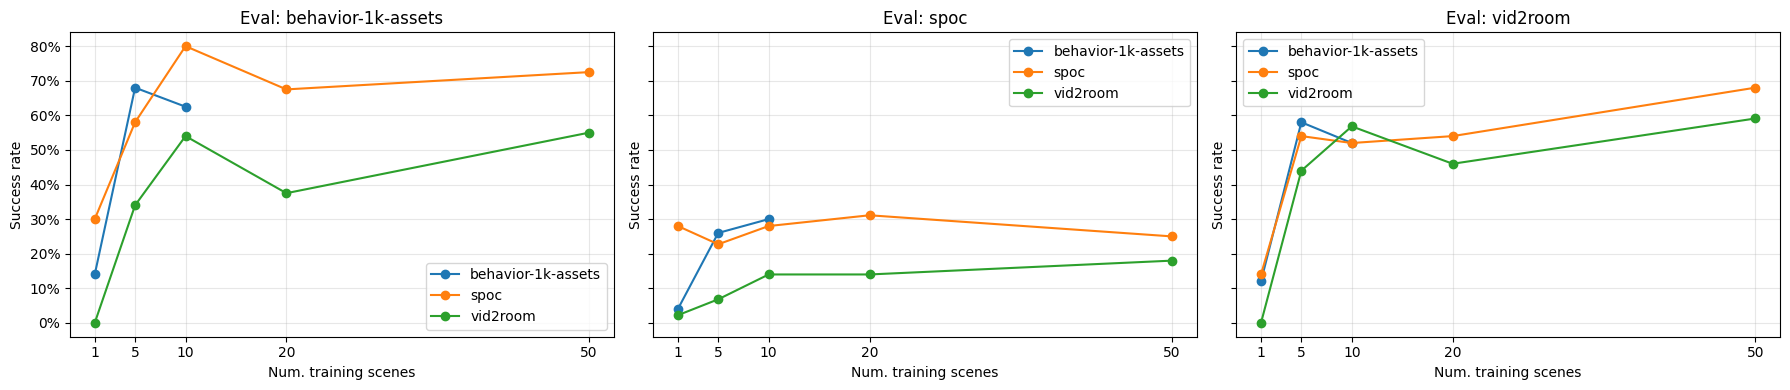

In [412]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Split policy_name into (training_dataset, num_scenes)
plot_df = df.copy()
split = plot_df["policy_name"].str.rsplit("-", n=1, expand=True)
plot_df["training_dataset"] = split[0]
plot_df["num_scenes"] = split[1].astype(int)

eval_datasets = sorted(plot_df["dataset_name"].unique())
training_datasets = sorted(plot_df["training_dataset"].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(eval_datasets), figsize=(6 * len(eval_datasets), 4), sharey=True)
if len(eval_datasets) == 1:
    axes = [axes]

for ax, eval_ds in zip(axes, eval_datasets):
    subset = plot_df[plot_df["dataset_name"] == eval_ds]
    for i, train_ds in enumerate(training_datasets):
        line = subset[subset["training_dataset"] == train_ds].sort_values("num_scenes")
        if line.empty:
            continue
        ax.plot(line["num_scenes"], line["rate"], marker="o", color=colors[i % len(colors)], label=train_ds)
    ax.set_title(f"Eval: {eval_ds}")
    ax.set_xlabel("Num. training scenes")
    ax.set_ylabel("Success rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add x ticks for 1, 5, 10, 20, 50
    # ax.set_xscale('log')
    ax.set_xticks([1, 5, 10, 20, 50])
    ax.set_xticklabels([1, 5, 10, 20, 50])
    
fig.tight_layout()
plt.show()